In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.datasets as tds
import torchvision.utils as tu

import matplotlib.pyplot as plt

In [3]:
mnist_train = tds.FashionMNIST(
    root=dataset_root,
    download=True,
    train=True,
)

mnist_eval = tds.FashionMNIST(
    root=dataset_root,
    download=True,
    train=False,
)


In [4]:
class MnistBinary:
    def __init__(self, mnist: tds.MNIST, label0: int, label1: int):
        d0 = mnist.data[mnist.targets == label0]
        d1 = mnist.data[mnist.targets == label1]

        l0 = torch.zeros(len(d0))
        l1 = torch.ones(len(d1))
        
        self.data = torch.cat((d0, d1))
        self.targets = torch.cat((l0, l1))

    def __getitem__(self, index: int):
        return (self.data[index], self.targets[index])

    def __len__(self):
        return len(self.data)

    def random_grid(self, sz: int):
        samples_ix = torch.randint(low=0, high=len(self.data) - 1, size=(sz,))
        samples = self.data[samples_ix]
        samples = samples[:, None, ...]
        grid = tu.make_grid(samples)
        return grid.permute(1, 2, 0)        

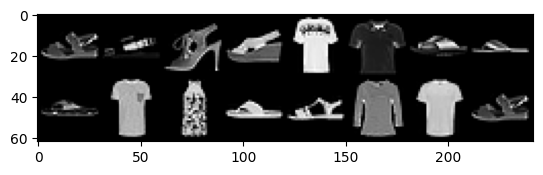

In [5]:
train = MnistBinary(mnist_train, 0, 5)
val = MnistBinary(mnist_eval, 0, 5)
plt.imshow(val.random_grid(16))

In [6]:
batchsize = 32

train_loader = tud.DataLoader(train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(val, batch_size=batchsize, shuffle=True)

In [7]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz)
        self.lin2 = nn.Linear(hidden_sz, out_sz)

    def forward(self, x):
        x = x.view(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.sigmoid(x)
        return x
        

In [8]:
testmodel = MyNn(28 * 28, 1)
test = train[0][0].unsqueeze(0).float()
testmodel(test)

tensor([[0.0110]], grad_fn=<SigmoidBackward0>)

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MyNn(28 * 28, 1, hidden_sz=8).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
lossfn = nn.L1Loss()
epochs = 10

for epoch in range(epochs):
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 1))
        loss.backward()
        optimizer.step()

    losses = []
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.float().to(device)
            outs = model(images)
            loss = lossfn(outs, targets.view(-1, 1))
            losses.append(loss)
    print("Val loss {}".format(torch.Tensor(losses).mean()))

Val loss 0.0075042410753667355
Val loss 0.0057952674105763435
Val loss 0.004921106621623039
Val loss 0.004359445068985224
Val loss 0.004287376068532467
Val loss 0.004204417113214731
Val loss 0.003913104999810457
Val loss 0.004162213299423456
Val loss 0.003774865297600627
Val loss 0.0034370175562798977


In [10]:
total = len(val)
correct = 0
with torch.no_grad():
    for image, target in val:
        pred = model(image.float().to(device))
        if (pred.round() == target):
            correct += 1
            
    print("{:.2f}% correct".format(100*correct/total))

99.65% correct


In [11]:
from ipywidgets import interact

@interact(index=(0, len(val) - 1, 1))
def draw_preds(index=0):
    with torch.no_grad():
        image = val[index][0]
        pred = model(image.float().to(device))
        # pred = pred, dim=1)
        plt.imshow(image.float().cpu().squeeze(), cmap='gray')
        print(pred, pred.round())

interactive(children=(IntSlider(value=0, description='index', max=1999), Output()), _dom_classes=('widget-inte…

How does such a simple neural network score >99% correct on binary classification? Well...

tensor([[0.0731]], device='cuda:0')


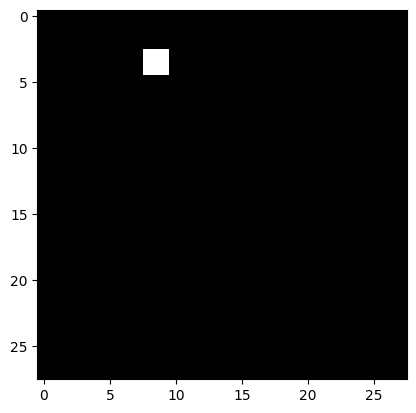

In [12]:
with torch.no_grad():
    test = torch.zeros(28,28)
    test[3:5, 8:10] = 255
    plt.imshow(test, cmap='gray')
    pred = model(test.float().to(device))
    print(pred)

A 2x2 white square in the upper left quadrant is good enough to be classified as a shirt. If you look at the training images, the majority of the sandals never have any white pixels in this region. The NN is able to exploit this fact, and confidently predict shirts without learning a more complicated idea of what a shirt is.

What would our score be if we make a "model" that classifies based on those four pixels?

In [13]:
total = len(val)
correct = 0
with torch.no_grad():
    for image, target in val:
        if image[3:5, 8:10].sum() > 10:
            pred = 0
        else:
            pred = 1
        if (pred == target):
            correct += 1
            
    print("{:.2f}% correct".format(100*correct/total))

98.80% correct
